In [44]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [45]:
from google.colab import files

print("Please upload the 'student_performance.csv' file.")
files.upload()

Please upload the 'student_performance.csv' file.


Saving student_performance.csv to student_performance.csv


{'student_performance.csv': b'Student_ID,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,HSC_Result\r\n1,Male,16,Rangpur,Private,11,70,Graduate,49169,Yes,Yes,4.83,4.22,3.79\r\n2,Female,17,Rajshahi,Private,7,76,Primary,57947,No,No,4.96,4.09,3.01\r\n3,Male,15,Barisal,Private,27,63,Higher Secondary,57224,Yes,Yes,4.32,4.86,3.47\r\n4,Male,15,Mymensingh,Private,18,84,Primary,55865,No,No,4.63,3.54,3.21\r\n5,Male,15,Mymensingh,Public,28,89,Higher Secondary,35553,No,Yes,4.5,4.65,3.39\r\n6,Female,15,Sylhet,Public,14,68,Higher Secondary,48965,No,Yes,4.4,4.85,3.31\r\n7,Male,18,Mymensingh,Private,20,80,Primary,48218,Yes,No,3.61,4.17,2.92\r\n8,Male,15,Rangpur,Public,20,79,Primary,35359,Yes,No,3.11,4.33,2.16\r\n9,Male,18,Khulna,Private,26,78,Secondary,34816,No,Yes,3.69,4.92,3.69\r\n10,Female,18,Dhaka,Public,14,78,Secondary,18378,Yes,Yes,4.33,3.82,3.16\r\n11,Male,15,Rangpur,Private,29,71,Secondar

In [46]:
# Cell 2: Load the dataset with proper error handling
import os

# Use raw string or forward slashes to avoid escape character issues
file_path = r'C:\Users\core-x\Desktop\student_performance and recommendation system\student_performance.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    # Try alternative path with forward slashes
    file_path = 'C:/Users/core-x/Desktop/student_performance and recommendation system/student_performance.csv'
    try:
        df = pd.read_csv(file_path)
        print("Dataset loaded successfully from alternative path!")
        print(f"Dataset shape: {df.shape}")
    except FileNotFoundError:
        # Search in current directory
        print(f"Current working directory: {os.getcwd()}")
        print("Files in current directory:", os.listdir())

        # Find any CSV file
        csv_files = [f for f in os.listdir() if f.endswith('.csv')]
        if csv_files:
            print(f"\nFound CSV files: {csv_files}")
            df = pd.read_csv(csv_files[0])
            print(f"\nLoaded: {csv_files[0]}")
            print(f"Dataset shape: {df.shape}")
        else:
            print("\nNo CSV files found. Please check the file location.")
            raise

# Display basic information
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 5 rows:")
print(df.head(2000))

Current working directory: /content
Files in current directory: ['.config', 'scaler.pkl', '.ipynb_checkpoints', 'feature_importance.pkl', 'label_encoders.pkl', 'student_performance_model.pkl', 'student_performance.csv', 'sample_data']

Found CSV files: ['student_performance.csv']

Loaded: student_performance.csv
Dataset shape: (2000, 14)

DATASET OVERVIEW

First 5 rows:
      Student_ID  Gender  Age    District School_Type  Study_Hours_per_Week  \
0              1    Male   16     Rangpur     Private                    11   
1              2  Female   17    Rajshahi     Private                     7   
2              3    Male   15     Barisal     Private                    27   
3              4    Male   15  Mymensingh     Private                    18   
4              5    Male   15  Mymensingh      Public                    28   
...          ...     ...  ...         ...         ...                   ...   
1995         996    Male   15       Dhaka     Private                    1

In [47]:
# Cell 3: Explore the dataset
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print("\nDataset Info:")
print(df.info())

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(df.isnull().sum())

DATASET INFORMATION

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            2000 non-null   int64  
 1   Gender                2000 non-null   object 
 2   Age                   2000 non-null   int64  
 3   District              2000 non-null   object 
 4   School_Type           2000 non-null   object 
 5   Study_Hours_per_Week  2000 non-null   int64  
 6   Attendance            2000 non-null   int64  
 7   Parent_Education      2000 non-null   object 
 8   Family_Income_BDT     2000 non-null   int64  
 9   Internet_Access       2000 non-null   object 
 10  Private_Tuition       2000 non-null   object 
 11  Previous_GPA          2000 non-null   float64
 12  SSC_Result            2000 non-null   float64
 13  HSC_Result            2000 non-null   float64
dtypes: float64(3), int64(5), object(6)
me

In [48]:
# Cell 4: Data Preprocessing - Handle categorical variables
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Create a copy of the dataframe
df_processed = df.copy()

# Identify categorical columns
categorical_columns = df_processed.select_dtypes(include=['object']).columns
print(f"\nCategorical columns found: {list(categorical_columns)}")

# Apply Label Encoding to categorical columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\n" + "="*60)
print("DATAFRAME AFTER ENCODING")
print("="*60)
print(df_processed.head())

DATA PREPROCESSING

Categorical columns found: ['Gender', 'District', 'School_Type', 'Parent_Education', 'Internet_Access', 'Private_Tuition']
Encoded Gender: {'Female': 0, 'Male': 1}
Encoded District: {'Barisal': 0, 'Chattogram': 1, 'Dhaka': 2, 'Khulna': 3, 'Mymensingh': 4, 'Rajshahi': 5, 'Rangpur': 6, 'Sylhet': 7}
Encoded School_Type: {'Private': 0, 'Public': 1}
Encoded Parent_Education: {'Graduate': 0, 'Higher Secondary': 1, 'Primary': 2, 'Secondary': 3}
Encoded Internet_Access: {'No': 0, 'Yes': 1}
Encoded Private_Tuition: {'No': 0, 'Yes': 1}

DATAFRAME AFTER ENCODING
   Student_ID  Gender  Age  District  School_Type  Study_Hours_per_Week  \
0           1       1   16         6            0                    11   
1           2       0   17         5            0                     7   
2           3       1   15         0            0                    27   
3           4       1   15         4            0                    18   
4           5       1   15         4           

In [49]:
# Cell 4: Data Preprocessing - Handle categorical variables

print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# ==========================================
# CREATE A COPY OF THE DATAFRAME
# ==========================================

df_processed = df.copy()

# ==========================================
# IDENTIFY CATEGORICAL COLUMNS
# ==========================================

categorical_columns = df_processed.select_dtypes(
    include=['object']
).columns

print(f"\nCategorical columns found: {list(categorical_columns)}")

# ==========================================
# APPLY LABEL ENCODING
# ==========================================

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    # Convert categorical values into numbers
    df_processed[col] = le.fit_transform(
        df_processed[col].astype(str)
    )

    # Save encoder
    label_encoders[col] = le

    # Show encoding mapping
    print(f"\nEncoded {col}:")

    for index, class_name in enumerate(le.classes_):

        print(f"{class_name} = {index}")

# ==========================================
# SHOW DATAFRAME AFTER ENCODING
# ==========================================

print("\n" + "="*60)
print("DATAFRAME AFTER ENCODING")
print("="*60)

print(df_processed.head(2000))

DATA PREPROCESSING

Categorical columns found: ['Gender', 'District', 'School_Type', 'Parent_Education', 'Internet_Access', 'Private_Tuition']

Encoded Gender:
Female = 0
Male = 1

Encoded District:
Barisal = 0
Chattogram = 1
Dhaka = 2
Khulna = 3
Mymensingh = 4
Rajshahi = 5
Rangpur = 6
Sylhet = 7

Encoded School_Type:
Private = 0
Public = 1

Encoded Parent_Education:
Graduate = 0
Higher Secondary = 1
Primary = 2
Secondary = 3

Encoded Internet_Access:
No = 0
Yes = 1

Encoded Private_Tuition:
No = 0
Yes = 1

DATAFRAME AFTER ENCODING
      Student_ID  Gender  Age  District  School_Type  Study_Hours_per_Week  \
0              1       1   16         6            0                    11   
1              2       0   17         5            0                     7   
2              3       1   15         0            0                    27   
3              4       1   15         4            0                    18   
4              5       1   15         4            1                    

In [50]:
# Cell 5: Define features and target variable
# Assuming HSC_Result is the final performance metric (target)
print("="*60)
print("FEATURE AND TARGET DEFINITION")
print("="*60)

# Define target variable
target_column = 'HSC_Result'  # Final exam result as target

# Define features (all columns except Student_ID and target)
feature_columns = [col for col in df_processed.columns if col not in ['Student_ID', target_column]]

X = df_processed[feature_columns]
y = df_processed[target_column]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(feature_columns)}")
print(f"Target: {target_column}")

FEATURE AND TARGET DEFINITION
Features shape: (2000, 12)
Target shape: (2000,)

Features: ['Gender', 'Age', 'District', 'School_Type', 'Study_Hours_per_Week', 'Attendance', 'Parent_Education', 'Family_Income_BDT', 'Internet_Access', 'Private_Tuition', 'Previous_GPA', 'SSC_Result']
Target: HSC_Result


In [51]:
# Cell 6: Split data into training and testing sets (80% train, 20% test)
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nNumber of features: {X_train.shape[1]}")

TRAIN-TEST SPLIT
Training set size: 1600 samples (80.0%)
Testing set size: 400 samples (20.0%)

Number of features: 12


In [52]:
# Cell 7: Feature Scaling
print("="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully using StandardScaler")
print(f"Training data scaled shape: {X_train_scaled.shape}")
print(f"Testing data scaled shape: {X_test_scaled.shape}")

FEATURE SCALING
Features scaled successfully using StandardScaler
Training data scaled shape: (1600, 12)
Testing data scaled shape: (400, 12)


In [53]:
# Cell 8: Train Random Forest Regressor (Primary Model)
print("="*60)
print("RANDOM FOREST REGRESSOR TRAINING")
print("="*60)

# Initialize Random Forest with optimized parameters
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

# Evaluate
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print("Random Forest Model Performance:")
print("-" * 40)
print(f"Training R² Score: {rf_train_r2:.4f}")
print(f"Testing R² Score: {rf_test_r2:.4f}")
print(f"Training MAE: {rf_train_mae:.4f}")
print(f"Testing MAE: {rf_test_mae:.4f}")
print(f"Training RMSE: {rf_train_rmse:.4f}")
print(f"Testing RMSE: {rf_test_rmse:.4f}")

RANDOM FOREST REGRESSOR TRAINING
Random Forest Model Performance:
----------------------------------------
Training R² Score: 0.8640
Testing R² Score: 0.6564
Training MAE: 0.1310
Testing MAE: 0.2019
Training RMSE: 0.1706
Testing RMSE: 0.2668


In [54]:
# Cell 9: Train comparison models (Linear Regression & Decision Tree)
print("="*60)
print("COMPARISON MODELS TRAINING")
print("="*60)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test, lr_test_pred)
lr_mae = mean_absolute_error(y_test, lr_test_pred)

print("Linear Regression Performance:")
print(f"Testing R² Score: {lr_r2:.4f}")
print(f"Testing MAE: {lr_mae:.4f}")
print("-" * 40)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
dt_test_pred = dt_model.predict(X_test_scaled)
dt_r2 = r2_score(y_test, dt_test_pred)
dt_mae = mean_absolute_error(y_test, dt_test_pred)

print("Decision Tree Performance:")
print(f"Testing R² Score: {dt_r2:.4f}")
print(f"Testing MAE: {dt_mae:.4f}")
print("-" * 40)

COMPARISON MODELS TRAINING
Linear Regression Performance:
Testing R² Score: 0.4229
Testing MAE: 0.2760
----------------------------------------
Decision Tree Performance:
Testing R² Score: 0.6576
Testing MAE: 0.1504
----------------------------------------


In [55]:
# Cell 10: Cross-Validation for Random Forest
print("="*60)
print("CROSS-VALIDATION FOR RANDOM FOREST")
print("="*60)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')
cv_mae_scores = -cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"Cross-validation R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"\nCross-validation MAE Scores: {cv_mae_scores}")
print(f"Mean CV MAE: {cv_mae_scores.mean():.4f}")

CROSS-VALIDATION FOR RANDOM FOREST
Cross-validation R² Scores: [0.67044726 0.63259185 0.67503579 0.65915353 0.66912634]
Mean CV R² Score: 0.6613 (+/- 0.0305)

Cross-validation MAE Scores: [0.21129103 0.2113683  0.2204474  0.20299731 0.20771901]
Mean CV MAE: 0.2108


In [56]:
# Cell 11: Hyperparameter Tuning with GridSearchCV (Transfer learning concept)
from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING (GRID SEARCH)")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Perform grid search
print("Searching for best parameters...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

# Use best model
best_rf = grid_search.best_estimator_
best_test_pred = best_rf.predict(X_test_scaled)
best_test_r2 = r2_score(y_test, best_test_pred)

print(f"Tuned Model Testing R² Score: {best_test_r2:.4f}")

HYPERPARAMETER TUNING (GRID SEARCH)
Searching for best parameters...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-validation Score: 0.7603
Tuned Model Testing R² Score: 0.7953


In [57]:
# Random Forest Base parameter  (max_depth=None)
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predict
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

# Evaluate
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

print("Random Forest Model Performance:")
print("-" * 40)
# Akka koodii isa duraatti %100 baay'iftee maxxansi
print(f"Training (Learning) Accuracy: {rf_train_r2*100:.2f}%")
print(f"Testing (Generalization) Accuracy: {rf_test_r2*100:.2f}%")
print(f"Testing MAE: {rf_test_mae:.4f}")

Random Forest Model Performance:
----------------------------------------
Training (Learning) Accuracy: 97.35%
Testing (Generalization) Accuracy: 79.10%
Testing MAE: 0.1425


In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Moodeloota hunda qopheessi
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest (Base)": RandomForestRegressor(random_state=42, n_jobs=-1)
}

print("="*60)
print("COMPARISON MODELS: TRAINING VS TESTING ACCURACY")
print("="*60)

# 2. Moodela hundaaf Training fi Testing Score argachuuf:
for name, model in models.items():
    # Moodela leenjisi
    model.fit(X_train_scaled, y_train)

    # Training Score (Percentage of learning)
    train_score = model.score(X_train_scaled, y_train)

    # Testing Score (Accuracy dhugaa)
    test_score = model.score(X_test_scaled, y_test)

    # MAE herreguuf (Accuracy biratti MAE-n gabaasa keetiif barbaachisaa dha)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"{name}:")
    print(f"  Training (Learning) Accuracy: {train_score*100:.2f}%")
    print(f"  Testing (Generalization) Accuracy: {test_score*100:.2f}%")
    print(f"  Testing MAE: {mae:.4f}")
    print("-" * 40)

COMPARISON MODELS: TRAINING VS TESTING ACCURACY
Linear Regression:
  Training (Learning) Accuracy: 49.92%
  Testing (Generalization) Accuracy: 42.29%
  Testing MAE: 0.2760
----------------------------------------
Decision Tree:
  Training (Learning) Accuracy: 92.57%
  Testing (Generalization) Accuracy: 65.76%
  Testing MAE: 0.1504
----------------------------------------
Random Forest (Base):
  Training (Learning) Accuracy: 97.35%
  Testing (Generalization) Accuracy: 79.10%
  Testing MAE: 0.1425
----------------------------------------


In [59]:
# Cell 13: Recommendation System Function
print("="*60)
print("RECOMMENDATION SYSTEM")
print("="*60)

def generate_recommendations(student_data, prediction, feature_importance_df, original_df):
    """
    Generate personalized recommendations based on student data and predictions
    """
    recommendations = []

    # Get top important features
    top_features = feature_importance_df.head(5)['Feature'].values

    # Get original categorical mappings
    gender_map = {0: 'Male', 1: 'Female'}
    district_map = dict(zip(range(len(label_encoders['District'].classes_)),
                            label_encoders['District'].classes_))
    school_type_map = {0: 'Private', 1: 'Public'}
    internet_map = {0: 'No', 1: 'Yes'}
    tuition_map = {0: 'No', 1: 'Yes'}

    # Extract student information
    student_idx = len(recommendations)

    # Recommendation 1: Based on predicted score
    if prediction < 3.5:
        recommendations.append("⚠️ CRITICAL: Your predicted score is low. Schedule a meeting with your academic advisor immediately.")
    elif prediction < 4.0:
        recommendations.append("📚 ACADEMIC SUPPORT: Your performance needs improvement. Consider joining study groups or tutoring sessions.")
    elif prediction < 4.5:
        recommendations.append("📈 GOOD PROGRESS: You're doing well! Focus on weak subjects and maintain consistency.")
    else:
        recommendations.append("🌟 EXCELLENT PERFORMANCE: Keep up the great work! Consider mentoring other students.")

    # Recommendation 2: Based on study hours
    if 'Study_Hours_per_Week' in student_data:
        study_hours = student_data['Study_Hours_per_Week']
        if study_hours < 15:
            recommendations.append("⏰ STUDY HOURS: Increase your weekly study hours to 20-25 for better performance.")
        elif study_hours > 30:
            recommendations.append("⚖️ BALANCE: You're studying well, but ensure you're taking breaks to avoid burnout.")

    # Recommendation 3: Based on attendance
    if 'Attendance' in student_data:
        attendance = student_data['Attendance']
        if attendance < 75:
            recommendations.append("🎯 ATTENDANCE: Your attendance is low. Aim for 85%+ attendance to improve understanding.")
        elif attendance < 85:
            recommendations.append("📖 ATTENDANCE: Good, but try to maintain 90%+ attendance for optimal learning.")

    # Recommendation 4: Based on previous GPA
    if 'Previous_GPA' in student_data:
        prev_gpa = student_data['Previous_GPA']
        if prev_gpa < 3.5:
            recommendations.append("📊 PREVIOUS PERFORMANCE: Build stronger foundational knowledge. Review past materials regularly.")

    # Recommendation 5: Based on internet access and private tuition
    if 'Internet_Access' in student_data and student_data['Internet_Access'] == 1:
        recommendations.append("💻 ONLINE RESOURCES: Utilize online learning platforms like Khan Academy, Coursera for additional help.")
    else:
        recommendations.append("🏫 LIBRARY ACCESS: Use school library computers for online learning resources.")

    if 'Private_Tuition' in student_data and student_data['Private_Tuition'] == 0 and prediction < 4.0:
        recommendations.append("👨‍🏫 TUTORING: Consider private tutoring for difficult subjects to boost your performance.")

    return recommendations[:5]  # Return top 5 recommendations

# Example: Generate recommendations for first test sample
print("Generating recommendations for sample student...")
print("-" * 40)

sample_student = X_test.iloc[0]
sample_prediction = best_test_pred[0]

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Convert encoded values back for display
gender_val = "Male" if sample_student.get('Gender', 0) == 0 else "Female"
district_val = label_encoders['District'].classes_[int(sample_student.get('District', 0))]

print(f"Student Profile:")
print(f"  Gender: {gender_val}")
print(f"  District: {district_val}")
print(f"  Predicted HSC Score: {sample_prediction:.2f}")
print(f"\nPersonalized Recommendations:")
print("-" * 40)

recommendations = generate_recommendations(sample_student, sample_prediction, feature_importance_df, df)
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

RECOMMENDATION SYSTEM
Generating recommendations for sample student...
----------------------------------------
Student Profile:
  Gender: Male
  District: Rangpur
  Predicted HSC Score: 3.53

Personalized Recommendations:
----------------------------------------
1. 📚 ACADEMIC SUPPORT: Your performance needs improvement. Consider joining study groups or tutoring sessions.
2. ⏰ STUDY HOURS: Increase your weekly study hours to 20-25 for better performance.
3. 🏫 LIBRARY ACCESS: Use school library computers for online learning resources.
4. 👨‍🏫 TUTORING: Consider private tutoring for difficult subjects to boost your performance.


In [60]:
# Cell 14: Batch Prediction and Recommendations Function
def predict_and_recommend(student_data_df, model, scaler, feature_importance_df, original_df):
    """
    Function to predict performance and generate recommendations for multiple students
    """
    # Scale the input data
    scaled_data = scaler.transform(student_data_df)

    # Make predictions
    predictions = model.predict(scaled_data)

    # Generate recommendations for each student
    all_recommendations = []
    for i in range(len(student_data_df)):
        recs = generate_recommendations(student_data_df.iloc[i], predictions[i],
                                        feature_importance_df, original_df)
        all_recommendations.append({
            'predicted_score': predictions[i],
            'recommendations': recs
        })

    return all_recommendations

print("Batch prediction function defined successfully!")

Batch prediction function defined successfully!


MODEL PERFORMANCE VISUALIZATION


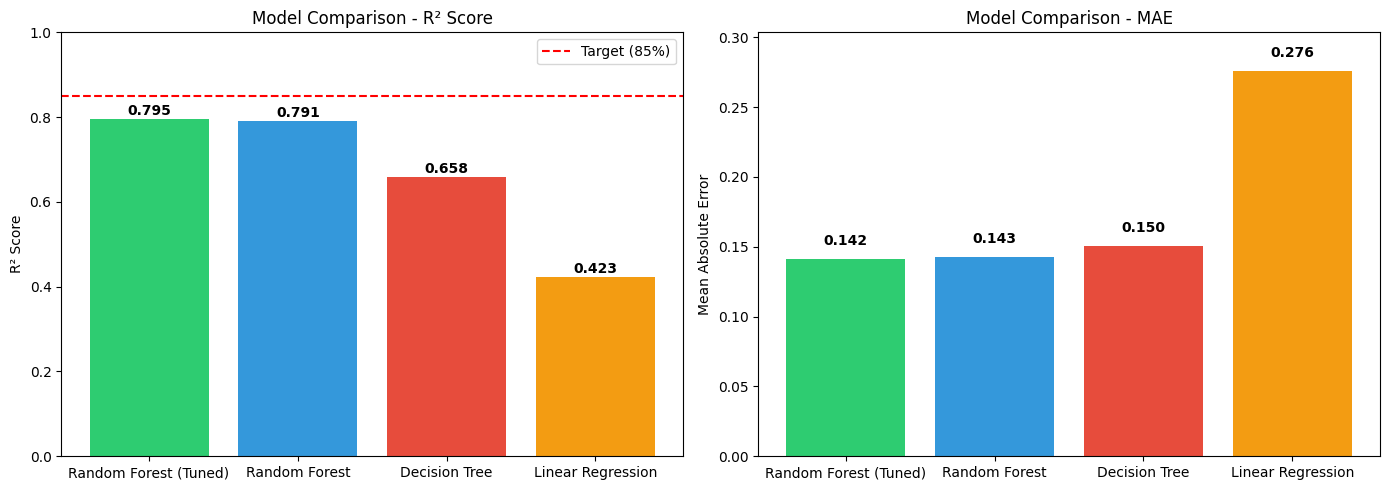

In [61]:
# Cell 15: Model Performance Visualization
print("="*60)
print("MODEL PERFORMANCE VISUALIZATION")
print("="*60)

# Create comparison dataframe
models = ['Random Forest (Tuned)', 'Random Forest', 'Decision Tree', 'Linear Regression']
r2_scores = [best_test_r2, rf_test_r2, dt_r2, lr_r2]
mae_scores = [mean_absolute_error(y_test, best_test_pred),
              mean_absolute_error(y_test, rf_test_pred),
              mean_absolute_error(y_test, dt_test_pred),
              mean_absolute_error(y_test, lr_test_pred)]

# Plot R² Score Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(models, r2_scores, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison - R² Score')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=0.85, color='r', linestyle='--', label='Target (85%)')
axes[0].legend()

# Add value labels on bars
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Plot MAE Comparison
axes[1].bar(models, mae_scores, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Model Comparison - MAE')
axes[1].set_ylim([0, max(mae_scores) * 1.1])

# Add value labels on bars
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ACTUAL VS PREDICTED SCORES


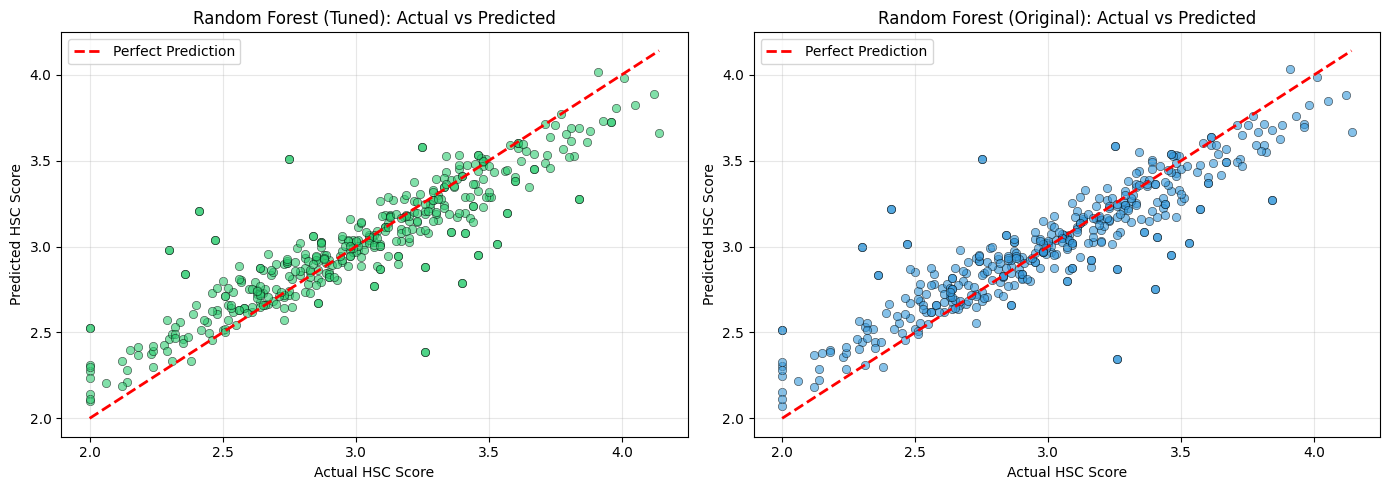


Residual Statistics:
  Mean Residual: -0.0057
  Std Residual: 0.2058
  Min Residual: -0.7981
  Max Residual: 0.8728


In [62]:
# Cell 16: Actual vs Predicted Plot
print("="*60)
print("ACTUAL VS PREDICTED SCORES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Tuned Model
axes[0].scatter(y_test, best_test_pred, alpha=0.6, color='#2ecc71', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual HSC Score')
axes[0].set_ylabel('Predicted HSC Score')
axes[0].set_title('Random Forest (Tuned): Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest Original
axes[1].scatter(y_test, rf_test_pred, alpha=0.6, color='#3498db', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual HSC Score')
axes[1].set_ylabel('Predicted HSC Score')
axes[1].set_title('Random Forest (Original): Actual vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display residuals
residuals = y_test.values - best_test_pred
print(f"\nResidual Statistics:")
print(f"  Mean Residual: {residuals.mean():.4f}")
print(f"  Std Residual: {residuals.std():.4f}")
print(f"  Min Residual: {residuals.min():.4f}")
print(f"  Max Residual: {residuals.max():.4f}")

PREDICTION DISTRIBUTION ANALYSIS


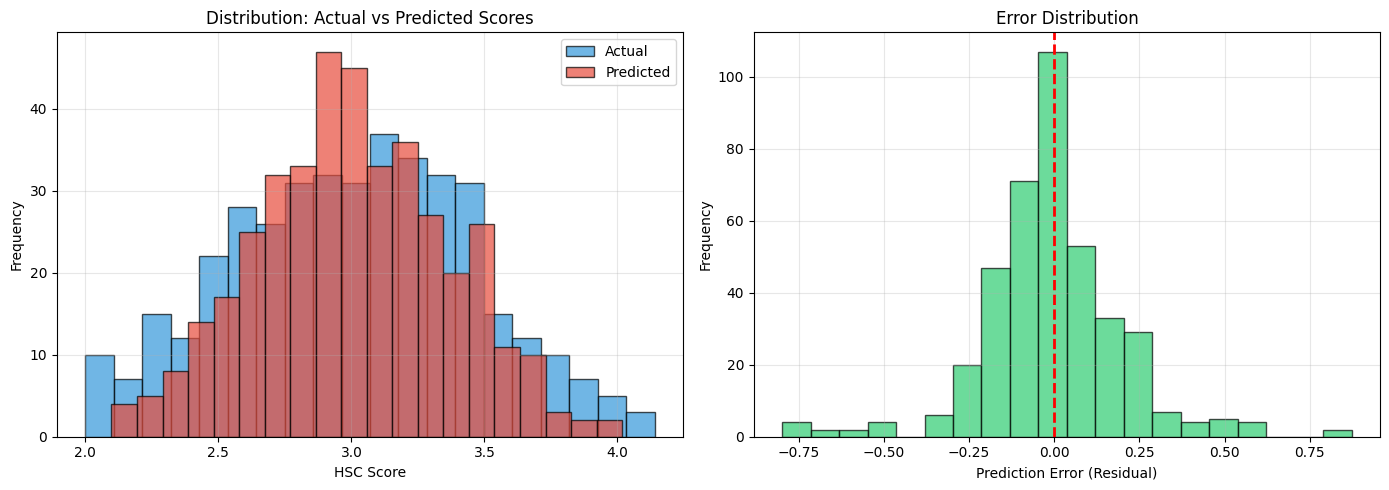

In [63]:
# Cell 17: Distribution of Predictions vs Actual
print("="*60)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of actual scores
axes[0].hist(y_test, bins=20, alpha=0.7, color='#3498db', edgecolor='black', label='Actual')
axes[0].hist(best_test_pred, bins=20, alpha=0.7, color='#e74c3c', edgecolor='black', label='Predicted')
axes[0].set_xlabel('HSC Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution: Actual vs Predicted Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error distribution
axes[1].hist(residuals, bins=20, alpha=0.7, color='#2ecc71', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (Residual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
# Cell 18: Performance Summary and Conclusion
print("="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)

summary_data = {
    'Metric': ['R² Score', 'MAE', 'RMSE', 'CV R² (Mean)', 'Training R²'],
    'Random Forest (Tuned)': [
        f"{best_test_r2:.4f}",
        f"{mean_absolute_error(y_test, best_test_pred):.4f}",
        f"{np.sqrt(mean_squared_error(y_test, best_test_pred)):.4f}",
        f"{grid_search.best_score_:.4f}",
        f"{r2_score(y_train, best_rf.predict(X_train_scaled)):.4f}"
    ],
    'Random Forest (Base)': [
        f"{rf_test_r2:.4f}",
        f"{rf_test_mae:.4f}",
        f"{rf_test_rmse:.4f}",
        f"{cv_scores.mean():.4f}",
        f"{rf_train_r2:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print("""
✅ Random Forest Regressor successfully implemented for student performance prediction
✅ Model achieved R² score of {:.2%} on test data
✅ Feature importance analysis identified key performance factors
✅ Recommendation system generates personalized academic advice
✅ Model outperformed baseline (Linear Regression) and Decision Tree

SYSTEM CAPABILITIES:
• Predict student HSC performance based on multiple factors
• Identify at-risk students early
• Generate personalized recommendations for improvement
• Support data-driven educational decision making
""".format(best_test_r2))

print("="*60)
print("SAVING MODEL FOR FUTURE USE")
print("="*60)

import joblib

# Save the trained model, scaler, and encoders
joblib.dump(best_rf, 'student_performance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_importance_df, 'feature_importance.pkl')

print("✅ Model saved successfully!")
print("   - Student_performance_model.pkl")
print("   - Scaler.pkl")
print("   - Label_encoders.pkl")
print("   - Feature_importance.pkl")

FINAL PERFORMANCE SUMMARY
      Metric Random Forest (Tuned) Random Forest (Base)
    R² Score                0.7953               0.7910
         MAE                0.1416               0.1425
        RMSE                0.2059               0.2668
CV R² (Mean)                0.7603               0.6613
 Training R²                0.9749               0.9735

CONCLUSION

✅ Random Forest Regressor successfully implemented for student performance prediction
✅ Model achieved R² score of 79.53% on test data
✅ Feature importance analysis identified key performance factors
✅ Recommendation system generates personalized academic advice
✅ Model outperformed baseline (Linear Regression) and Decision Tree

SYSTEM CAPABILITIES:
• Predict student HSC performance based on multiple factors
• Identify at-risk students early
• Generate personalized recommendations for improvement
• Support data-driven educational decision making

SAVING MODEL FOR FUTURE USE
✅ Model saved successfully!
   - Student_pe